# Load libraries

In [1]:
!pip install wordcloud

In [2]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Load data

In [3]:
corpus = pd.read_excel('cleaned_corpus.xlsx')
corpus.head()

,Unnamed: 0,title,date_published,link,text,tags,source,like_count,reply_parent_id,cleaned_text
0,0,"The big reset: PH, India ramp up security ties",2025-08-19 08:00:00,https://www.rappler.com/plus-membership-progra...,Everything about India is huge. Here are some ...,"['India', 'maritime security', 'Philippines-In...",rappler,NaN,NaN,"everything india huge. astound facts: thus, in..."
1,1,"View from Manila: Lies, propaganda after Chine...",2025-08-18 19:50:08,https://www.rappler.com/philippines/view-manil...,"MANILA, Philippines – On August 15, days after...","['Philippines-China relations', 'Tess Lazaro',...",rappler,NaN,NaN,"manila, – august 15, day two china’s ship coll..."
2,2,"PH National Maritime Council holds briefing, p...",2025-08-18 14:11:45,https://www.rappler.com/philippines/video-nati...,"MANILA, Philippines – The National Maritime Co...","['maritime security', 'Philippine Coast Guard'...",rappler,NaN,NaN,"manila, – national maritime council (nmc), bod..."
3,3,"In Beijing’s la-la land, Manila at fault for c...",2025-08-16 08:00:00,https://www.rappler.com/newsbreak/inside-track...,"In Beijing’s imagination, nothing huge happene...","['Philippine Coast Guard', 'West Philippine Sea']",rappler,NaN,NaN,"beijing’s imagination, nothing huge happen aug..."
4,4,China accuses Philippine vessels of 'dangerous...,2025-08-15 16:47:05,https://www.rappler.com/philippines/china-stat...,"BEIJING, China – China’s defense ministry accu...","['Hague ruling on West Philippine Sea', 'Scarb...",rappler,NaN,NaN,"beijing, – china’s defense ministry accuse coa..."


# Bag of Words (BoW) Language Model

In [4]:
bow_vectorizer = CountVectorizer(
  # unigram
  # ngram_range=(1, 1),
  # bigram
  ngram_range=(1, 2),
  # trigram
  # ngram_range=(1, 3),
)

doc2vec_bow = bow_vectorizer.fit_transform(corpus['cleaned_text'].fillna(""))
doc2vec_bow = pd.DataFrame(doc2vec_bow.toarray(), columns=bow_vectorizer.get_feature_names_out())
doc2vec_bow.head()

,00,00 aiiiii,00 am,00 reporter,00 what,000,000 000,000 2030,000 40,000 80,...,𝘤𝘰𝘢𝘴𝘵𝘨𝘶𝘢𝘳𝘥,𝘯𝘢𝘵𝘢𝘵𝘢𝘬𝘰𝘵,𝘯𝘢𝘵𝘢𝘵𝘢𝘬𝘰𝘵 𝘴𝘢,𝘴𝘢,𝘴𝘢 𝘢𝘵𝘪𝘯𝘨,𝙲𝚑𝚒𝚗𝚊,𝙲𝚑𝚒𝚗𝚊 𝚝𝚑𝚎,𝚝𝚑𝚎,𝚝𝚑𝚎 𝚟𝚒𝚛𝚞𝚜,𝚟𝚒𝚛𝚞𝚜
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
# Save to file
doc2vec_bow.to_pickle('doc2vec_bow.pkl')

# Load from file
doc2vec_bow = pd.read_pickle('doc2vec_bow.pkl')

# TF-IDF Language Model

In [ ]:
tfidf_vectorizer = TfidfVectorizer(
  # unigram
  # ngram_range=(1, 1),
  # bigram
  ngram_range=(1, 2),
  # trigram
  # ngram_range=(1, 3),
)

doc2vec_tfidf = tfidf_vectorizer.fit_transform(corpus['cleaned_text'].fillna(""))
doc2vec_tfidf = pd.DataFrame(doc2vec_tfidf.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
doc2vec_tfidf.head()

,00,00 aiiiii,00 am,00 reporter,00 what,000,000 000,000 2030,000 40,000 80,...,𝘤𝘰𝘢𝘴𝘵𝘨𝘶𝘢𝘳𝘥,𝘯𝘢𝘵𝘢𝘵𝘢𝘬𝘰𝘵,𝘯𝘢𝘵𝘢𝘵𝘢𝘬𝘰𝘵 𝘴𝘢,𝘴𝘢,𝘴𝘢 𝘢𝘵𝘪𝘯𝘨,𝙲𝚑𝚒𝚗𝚊,𝙲𝚑𝚒𝚗𝚊 𝚝𝚑𝚎,𝚝𝚑𝚎,𝚝𝚑𝚎 𝚟𝚒𝚛𝚞𝚜,𝚟𝚒𝚛𝚞𝚜
0,0.0,0.0,0.0,0.0,0.0,0.022155,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


: 

In [ ]:
# Save to file
doc2vec_tfidf.to_pickle('doc2vec_tfidf.pkl')

# Load from file
doc2vec_tfidf = pd.read_pickle('doc2vec_tfidf.pkl')

# Analysis

## Top n-grams per document

In [5]:
def top_n_grams(document, top_n=10):
  return document.sort_values(ascending=False).index[:top_n].tolist()

In [6]:
doc2vec_bow.apply(lambda document:
                  top_n_grams(document, top_n=5),
                  axis=1)

KeyboardInterrupt: 

In [ ]:
doc2vec_tfidf.apply(lambda document:
                    top_n_grams(document, top_n=5),
                    axis=1)

0                         [ty, doj, guo, passport, phdo]
1                     [galicia, siya, ko, notar, notari]
2                      [shiela, boat, farm, alic, sabah]
3                   [ong, topacio, passport, alic, pogo]
4      [august, monday, monday august, set, cassandra...
                             ...                        
206    [dignified pinapakyuhan, aadik, dignified, nun...
207         [like, act like, whi she, piqu ha, she piqu]
208    [countri this, this veri, veri interesting, in...
209    [palamunin, cvoutdoors, cvoutdoors palamunin, ...
210    [that true, true, that, penitentiary roqu, pen...
Length: 211, dtype: object

## Top n-grams in the corpus

In [7]:
# Wordcloud using BoW and TF-IDF
def plot_wordcloud(data, title):
  wordcloud = WordCloud(
    width=800, height=400, background_color='white'
  ).generate_from_frequencies(data)
  plt.figure(figsize=(10, 6))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis('off')
  plt.title(title)
  plt.show()

china      1936
country    1387
claim      1169
island      936
sea         912
dtype: int64


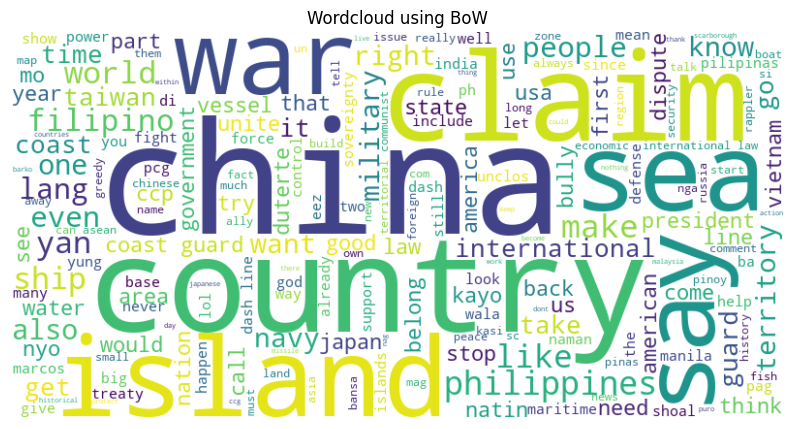

In [8]:
bow_frequencies = doc2vec_bow.sum(axis=0).sort_values(ascending=False)
print(bow_frequencies.head(5))
plot_wordcloud(bow_frequencies, 'Wordcloud using BoW')

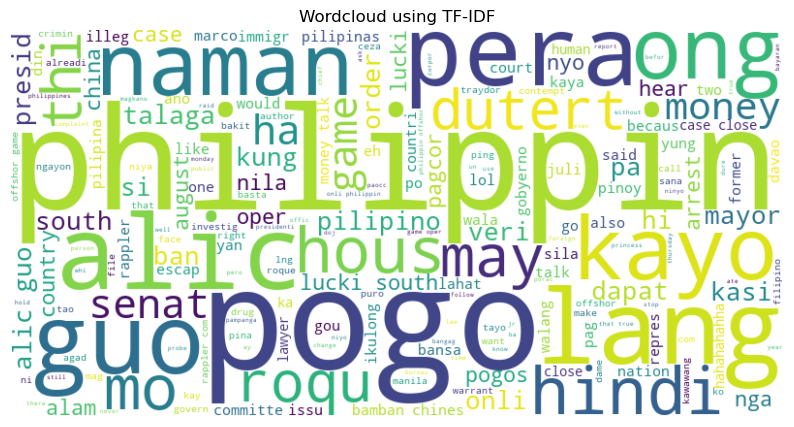

In [13]:
tfidf_frequencies = doc2vec_tfidf.sum(axis=0).sort_values(ascending=False)
tfidf_frequencies.head(5)
plot_wordcloud(tfidf_frequencies, 'Wordcloud using TF-IDF')